In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("diabetes.csv")
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#Basic information on dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
#Deriving the BMI section
bmi = df["BMI"]

<Axes: xlabel='BMI'>

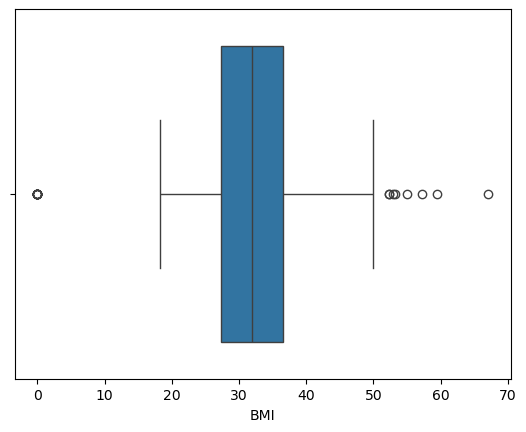

In [9]:
#Outliers visualisation (Boxplot)
sns.boxplot(x = bmi, data = df)

#### How to identify IQR components: ####
1. For every 2n even datapoints: Q1 and Q3 are respectively the median of smallest and largest values starting from the main median
2. For every 2n + 1 odd datapoints: similarly but with the mean ones and starting from the main mean
3. IQR = Q3 - Q1
4. min(IQR) = Q1 - 1.5* IQR
5. max(IQR) = Q3 + 1.5 * IQR
Notes: Always sort (in ascending order) the datasets before calculating IQR

In [11]:
#Describe the datasets and pre-built statistical variables
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [11]:
#For hand-writing calculation
bmi.sort_values()

q3 = bmi.quantile(0.75)
q1 = bmi.quantile(0.25)
iqr = q3 - q1
max_iqr = q3 + 1.5 * iqr
min_iqr = q1 - 1.5 * iqr

print(f"Q1 : {q1}, Q3 : {q3}")

Q1 : 27.3, Q3 : 36.6


<Axes: xlabel='BMI'>

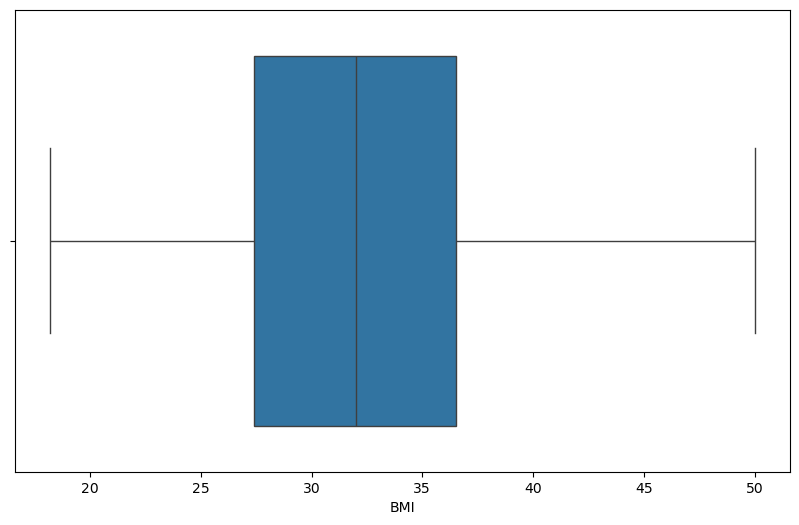

In [13]:
#Removing outliers process
new_df = df[(bmi <= max_iqr) & (bmi >= min_iqr)]

plt.figure(figsize = (10, 6))
sns.boxplot(x = new_df["BMI"], data = new_df)